In [1]:
# extract features from image.tif
import torch
import os

model_path = r"E:\Yiling\at_SIAT_research\z_result\20240430_1_train_binary_weight\train_dwq_sentinel2_cls_1\unet_epoch27_best_val.pth"

# Load the model
os.chdir(r'C:\Users\ZT\OneDrive\Studying\Yiling\00Research\202401_experiment\code')
model = torch.load(model_path)
model.eval()

feature_from_hook = {}
# Register the hook
def hook(module, input, output):
    feature_from_hook['hook_output'] = output
    print(output)

# layer_name 
# 'up4', -> [1, 64, 256, 256]         
# 'outc', -> [1, 9, 256, 256]
layer_name = 'up4'
layer = getattr(model, layer_name)
handle = layer.register_forward_hook(hook)




In [2]:
# dataloader
# dataloader, train or val?
from component.dataset import get_dataset_reader
from torch.utils import data

dataset_name = 'rgbn'
data_path = r'E:\Yiling\at_SIAT_research\1_dataset\dataset\dwq_sentinel2\train_val'
binary_class_index = 1
label_1_percent = 0.0
batch_size = 1
num_workers = 0

dataset_reader = get_dataset_reader(dataset_name)
val_dataset = dataset_reader(root_dir=data_path, is_train=0, transform= None, binary_class_index = binary_class_index, label_1_percent = label_1_percent)
val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)



load binary class list from file: E:\Yiling\at_SIAT_research\1_dataset\dataset\dwq_sentinel2\train_val\binary_class_1_val_0.0.txt
total val images: 2483


In [3]:
iterator_val_loader = iter(val_loader)


In [5]:
print(len(iterator_val_loader))
print(len(val_loader))

2483
2483


In [10]:
images, true_masks_cpu = next(iterator_val_loader)
print(images.sum(), true_masks_cpu.sum())

tensor(31601.7520) tensor(46725)


In [ ]:
for i, (images, true_masks_cpu) in enumerate(val_loader):
    images = images.to(device='cuda', dtype=torch.float32)
    print(images.shape)
    print(true_masks_cpu.shape)
    break

In [3]:
print(true_masks_cpu.sum())
print(true_masks_cpu.size())
print(next(model.parameters()).device)
print(images.device)

tensor(19469)
torch.Size([1, 256, 256])
cuda:0
cuda:0


In [4]:
input = images

# Run the model
with torch.no_grad():
    output = model(input)

# Remove the hook
handle.remove()

tensor([[[[0.2893, 0.7189, 0.3862,  ..., 0.0568, 0.4162, 0.1223],
          [0.2719, 0.3918, 0.2635,  ..., 0.0000, 0.0000, 0.0000],
          [0.0799, 0.5010, 0.0611,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.2688, 0.2539, 0.2189,  ..., 0.8641, 0.8108, 0.6054],
          [0.5656, 0.4009, 0.6100,  ..., 1.0456, 0.8999, 0.6226],
          [0.0000, 0.0000, 0.0074,  ..., 0.0048, 0.0000, 0.1196]],

         [[0.0442, 0.0000, 0.0000,  ..., 0.7283, 0.7813, 0.5054],
          [0.0000, 0.0000, 0.0000,  ..., 0.9733, 0.9107, 1.1202],
          [0.1664, 0.0609, 0.0000,  ..., 0.3883, 0.9922, 0.7079],
          ...,
          [0.0878, 0.2422, 0.0773,  ..., 0.0000, 0.0000, 0.0000],
          [0.2431, 0.0786, 0.0271,  ..., 0.0000, 0.0000, 0.0000],
          [0.0670, 0.3220, 0.1745,  ..., 0.0000, 0.0000, 0.2265]],

         [[0.1340, 0.1719, 0.0000,  ..., 0.6219, 0.6173, 0.5454],
          [0.0000, 0.0000, 0.0000,  ..., 0.9496, 0.9595, 0.8328],
          [0.0000, 0.0000, 0.0000,  ..., 0

In [5]:
feature_test = feature_from_hook['hook_output']

print(feature_test.shape)


torch.Size([1, 64, 256, 256])


In [7]:
feature_test_sum = feature_test.sum(axis=[2,3])
print(feature_test_sum.shape)
print(feature_test_sum.flatten())

torch.Size([1, 64])
tensor([40338.6367, 11015.4268,  9259.3125, 18564.4531, 30894.9336, 39528.5312,
         4136.5176, 38503.3555,  4347.0322,  2019.0580,  8118.1089,  6391.2925,
         4234.4106,  8710.9121, 37085.0977,  8822.8271,  9044.2959,  6258.6279,
         5792.2617,  7636.9351,  3385.2476,  9708.5977,  2516.9243,  6055.2100,
         6224.1914, 27042.0156,  6716.1362,  3874.7212,  2731.2339,  5079.9023,
         8861.1826, 35746.6797,  1306.2651,  8702.5967,  5186.9258,  9621.6250,
        13814.9248,  7757.5537,  2652.6362, 38141.5430,  6526.8174,  6755.1255,
         4661.1733, 28534.5000,  8534.3340,  5827.9678, 27033.7129, 35033.7617,
         2130.9771, 37603.7188, 43502.9062, 49517.7227,  8945.8779,  2045.3003,
        24565.2793,  7216.2861, 35679.5234, 35920.6172,  7486.2324, 48618.2578,
        23465.6367,  9780.8672,  6403.4946,  2773.2610], device='cuda:0')


In [15]:
feature_test_mean = torch.mean(feature_test, dim=[2,3]).flatten()
print(feature_test_mean)
print(feature_test_mean.shape)
# print(feature_test_mean == feature_test_sum/(256**2))

tensor([0.6155, 0.1681, 0.1413, 0.2833, 0.4714, 0.6032, 0.0631, 0.5875, 0.0663,
        0.0308, 0.1239, 0.0975, 0.0646, 0.1329, 0.5659, 0.1346, 0.1380, 0.0955,
        0.0884, 0.1165, 0.0517, 0.1481, 0.0384, 0.0924, 0.0950, 0.4126, 0.1025,
        0.0591, 0.0417, 0.0775, 0.1352, 0.5455, 0.0199, 0.1328, 0.0791, 0.1468,
        0.2108, 0.1184, 0.0405, 0.5820, 0.0996, 0.1031, 0.0711, 0.4354, 0.1302,
        0.0889, 0.4125, 0.5346, 0.0325, 0.5738, 0.6638, 0.7556, 0.1365, 0.0312,
        0.3748, 0.1101, 0.5444, 0.5481, 0.1142, 0.7419, 0.3581, 0.1492, 0.0977,
        0.0423], device='cuda:0')
torch.Size([64])


In [16]:
feature_test_var = torch.var(feature_test, dim=[2,3]).flatten()
print(feature_test_var)
print(feature_test_var.shape)

tensor([0.3090, 0.0569, 0.0374, 0.0975, 0.2464, 0.1222, 0.0268, 0.0949, 0.0383,
        0.0124, 0.0470, 0.0326, 0.0642, 0.0598, 0.3464, 0.0439, 0.0734, 0.0316,
        0.1236, 0.1880, 0.0200, 0.1822, 0.0228, 0.0587, 0.1029, 0.2938, 0.0615,
        0.0196, 0.0154, 0.0565, 0.0569, 0.3492, 0.0063, 0.0511, 0.0273, 0.0862,
        0.0784, 0.1584, 0.0263, 0.1182, 0.0922, 0.0640, 0.0377, 0.1354, 0.1232,
        0.0336, 0.3617, 0.3223, 0.0108, 0.1087, 0.1708, 0.1884, 0.0601, 0.0402,
        0.3929, 0.1606, 0.2725, 0.1474, 0.0392, 0.1455, 0.2090, 0.0577, 0.1285,
        0.0127], device='cuda:0')
torch.Size([64])


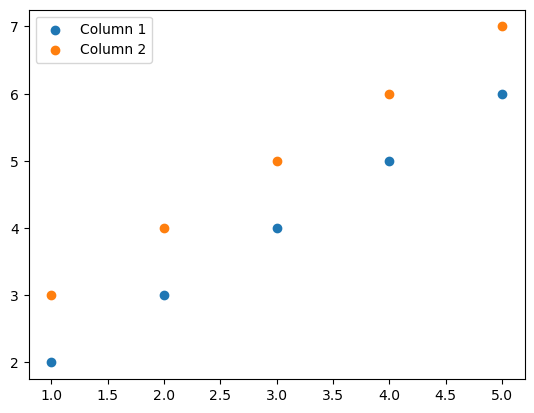

In [1]:
import matplotlib.pyplot as plt

# Assuming that `result_list` is your 2D list
result_list = [[1, 2, 3], 
               [2, 3, 4], 
               [3, 4, 5], 
               [4, 5, 6], 
               [5, 6, 7]]

# Extract the first column as x
x = [row[0] for row in result_list]

# Extract the rest of the columns as y
ys = [[row[i] for row in result_list] for i in range(1, len(result_list[0]))]

# Create a scatter plot for each y
for i, y in enumerate(ys):
    plt.scatter(x, y, label=f'Column {i+1}')

# Add a legend
plt.legend()

# Show the plot
plt.show()

In [12]:
import torch
# seed
torch.manual_seed(0)

s = torch.rand(10)
print(s)
t = torch.rand(10)
print(t)

difference = s - t
print(difference)
print(difference.sum())

print(difference.abs())

print(difference.abs().sum())

print(difference.abs().sum().item())


tensor([0.4963, 0.7682, 0.0885, 0.1320, 0.3074, 0.6341, 0.4901, 0.8964, 0.4556,
        0.6323])
tensor([0.3489, 0.4017, 0.0223, 0.1689, 0.2939, 0.5185, 0.6977, 0.8000, 0.1610,
        0.2823])
tensor([ 0.1474,  0.3665,  0.0662, -0.0368,  0.0135,  0.1156, -0.2076,  0.0964,
         0.2946,  0.3500])
tensor(1.2058)
tensor([0.1474, 0.3665, 0.0662, 0.0368, 0.0135, 0.1156, 0.2076, 0.0964, 0.2946,
        0.3500])
tensor(1.6946)
1.6945827007293701


In [6]:
import torch
index_list = [[1., 2, 3], [1, 2, 3], [1, 2, 3]]
# a1, a2, a3 = torch.tensor(index_list).mean(dim=0)
print(torch.tensor(index_list).mean(dim=0))
print(torch.tensor(index_list).mean(dim=0).tolist())
a1, a2, a3 = torch.tensor(index_list).mean(dim=0).tolist()
print(a1)
print(a2)
print(a3)

tensor([1., 2., 3.])
[1.0, 2.0, 3.0]
1.0
2.0
3.0


In [1]:
import matplotlib.pyplot as plt
def draw_scatter(x, y, title, label='feature map'):
    plt.scatter(x, y, label=label)
    # title
    plt.title(title)
    plt.legend()
    # plt.show()



done


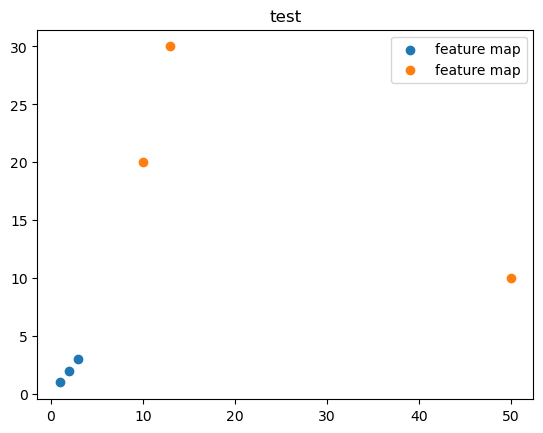

In [4]:
x = [1, 2, 3]
y = [1, 2, 3]
title = 'test'
draw_scatter(x, y, title)
x2 = [50, 10, 13]
y2 = [10, 20, 30]
draw_scatter(x2, y2, title)
print('done')


num_points: 4194304


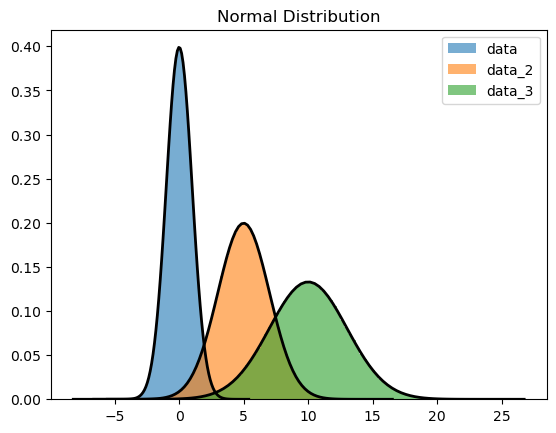

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def draw_normal_distribution(data, label='legend'):
    # Create histogram
    # plt.hist(data, bins=30, density=True, alpha=0.6, label=label)
    plt.hist(data, bins=100, density=True, alpha=0.6, label=label)

    # Add a best fit line
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    mu, std = np.mean(data), np.std(data)
    p = np.exp(-(x-mu)**2 / (2*std**2)) / (np.sqrt(2*np.pi*std**2))
    plt.plot(x, p, 'k', linewidth=2)

num_points = 256*256*64
print(f"num_points: {num_points}")
# Generate some data for this demonstration.
data = np.random.normal(0, 1, num_points)
draw_normal_distribution(data, label='data')

data_2 = np.random.normal(5, 2, num_points)
draw_normal_distribution(data_2, label='data_2')

data_3 = np.random.normal(10, 3, num_points)
draw_normal_distribution(data_3, label='data_3')

plt.legend()
plt.title("Normal Distribution")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_normal_distribution(data, label='legend', plt=plt):
    # Create histogram
    # plt.hist(data, bins=30, density=True, alpha=0.6, label=label)
    plt.hist(data, bins=100, density=True, alpha=0.6, label=label)

    # Add a best fit line
    xmin, xmax = plt.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    mu, std = np.mean(data), np.std(data)
    p = np.exp(-(x-mu)**2 / (2*std**2)) / (np.sqrt(2*np.pi*std**2))
    plt.plot(x, p, 'k', linewidth=2)
    plt.legend()

# Create some data
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)

# Create a figure and a set of subplots
size_per_subplot = 2
col_subplots = 8
row_subplots = 8
fig, axs = plt.subplots(col_subplots, row_subplots, figsize=(col_subplots * size_per_subplot, row_subplots * size_per_subplot))

num_points = 256*256*1
print(f"num_points: {num_points}")
# Plot data on each subplot
for col in range(col_subplots):
    for row in range(row_subplots):
        mean_1, std_1 = np.random.randint(1, 10, size=2)
        data_1 = np.random.normal(mean_1, std_1, num_points)
        draw_normal_distribution(data, label=f'label_0', plt=axs[col, row])
        mean_2, std_2 = np.random.randint(1, 10, size=2)
        data_2 = np.random.normal(mean_2, std_2, num_points)
        draw_normal_distribution(data_2, label=f'label_1', plt=axs[col, row])
        axs[col, row].set_title(f'Axis [{col}, {row}]')
# axs[0, 0].plot(x, y)
# axs[0, 0].set_title('Axis [0, 0]')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
# Add a legend to the figure
# handles, labels = axs[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center')
plt.show()

In [33]:
import torch
torch.manual_seed(5)
# Assuming `features` is your feature tensor of shape [1, 4, 2, 2]
# and `labels` is your label tensor of shape [1, 2, 2]
features = torch.rand(1, 4, 2, 2)
print(features)
labels = torch.randint(0, 2, (1, 2, 2))
print(labels)

# Reshape labels to match the shape of features
labels_expanded = labels.unsqueeze(1).expand_as(features)
print(labels_expanded)

# Use torch.where to extract features where label is 1
extracted_features = torch.where(labels_expanded == 1, features, torch.tensor(float('nan')))
print(extracted_features)

# Reshape the extracted features to [num_points, 4]
extracted_features_permute = extracted_features.permute(0, 2, 3, 1).reshape(-1, 4)
print(extracted_features_permute)

# Remove nan values
# extracted_features = extracted_features[~torch.isnan(extracted_features)]
extracted_features_permute = extracted_features_permute[~torch.isnan(extracted_features_permute)]

print(extracted_features_permute)

print(extracted_features_permute.reshape(-1, 4))

tensor([[[[0.8303, 0.1261],
          [0.9075, 0.8199]],

         [[0.9201, 0.1166],
          [0.1644, 0.7379]],

         [[0.0333, 0.9942],
          [0.6064, 0.5646]],

         [[0.0724, 0.6593],
          [0.7150, 0.5793]]]])
tensor([[[1, 0],
         [1, 1]]])
tensor([[[[1, 0],
          [1, 1]],

         [[1, 0],
          [1, 1]],

         [[1, 0],
          [1, 1]],

         [[1, 0],
          [1, 1]]]])
tensor([[[[0.8303,    nan],
          [0.9075, 0.8199]],

         [[0.9201,    nan],
          [0.1644, 0.7379]],

         [[0.0333,    nan],
          [0.6064, 0.5646]],

         [[0.0724,    nan],
          [0.7150, 0.5793]]]])
tensor([[0.8303, 0.9201, 0.0333, 0.0724],
        [   nan,    nan,    nan,    nan],
        [0.9075, 0.1644, 0.6064, 0.7150],
        [0.8199, 0.7379, 0.5646, 0.5793]])
tensor([0.8303, 0.9201, 0.0333, 0.0724, 0.9075, 0.1644, 0.6064, 0.7150, 0.8199,
        0.7379, 0.5646, 0.5793])
tensor([[0.8303, 0.9201, 0.0333, 0.0724],
        [0.9075, 0.16

In [6]:
import torch
import numpy as np

def torch_cov(x:torch.Tensor):
    '''计算协方差矩阵
    Args:
        x: 二维张量 (batch_size, features)
        rowvar: 如果为 True，则假设 x 的形状是 (features, batch_size)，否则假设 x 的形状是 (batch_size, features)
    Returns:
        协方差矩阵
    '''
    # 计算均值
    mean = torch.mean(x, dim=0).unsqueeze(0)  # 增加一维，以便进行广播
    # 计算中心化数据（每个变量减去其均值）
    x_centered = x - mean
    # 计算协方差矩阵
    cov_matrix = (x_centered.T @ x_centered) / (x_centered.size(0) - 1)
    return cov_matrix


# 真实图像和生成图像的特征
real_features = torch.tensor([[[[1., 2],
                                [3, 4]],

                                [[5, 6],
                                [7, 8]],

                                [[1, 2],
                                [3, 4]],

                                [[5, 6],
                                [7, 8]]]])
fake_features = torch.tensor([[[[1., 2],
                                [3, 4]],

                                [[5, 6],
                                [7, 8]],

                                [[1, 2],
                                [3, 4]],

                                [[5, 6],
                                [7, 8]]]])
# real_features = torch.rand(1, 4, 3, 3)
# fake_features = torch.rand(1, 4, 2, 2)
# 计算均值和协方差矩阵

print(real_features.shape)
mu_real = torch.mean(real_features, dim=[0,2,3])
mu_fake = torch.mean(fake_features, dim=[0,2,3])
print(mu_real, mu_fake)

real_features_permute = real_features.permute(0, 2, 3, 1).reshape(-1, 4)
print(real_features_permute)
sigma_real = torch.cov(real_features_permute.t())
# sigma_real = torch_cov(real_features_permute)
print(sigma_real)

fake_features_permute = fake_features.permute(0, 2, 3, 1).reshape(-1, 4)
sigma_fake = torch.cov(fake_features_permute.t())
# sigma_fake = torch_cov(fake_features_permute)
print(sigma_fake)

# # 计算Fréchet距离
# ssdiff = np.sum((mu_fake - mu_real) ** 2.0)
# covmean = sqrtm(sigma_real.dot(sigma_fake))

# fid = ssdiff + np.trace(sigma_real + sigma_fake - 2.0 * covmean)
# F范数
mean_F_norm = torch.norm(mu_real - mu_fake, p=2).item()
print(mean_F_norm)
# 方差
tr_cov = torch.trace(sigma_real + sigma_fake - 2 * torch.sqrt(sigma_real @ sigma_fake))
print(sigma_real + sigma_fake - 2 * torch.sqrt(sigma_real @ sigma_fake))
print(tr_cov)

fid = mean_F_norm + tr_cov
print('FID: ', fid)

torch.Size([1, 4, 2, 2])
tensor([2.5000, 6.5000, 2.5000, 6.5000]) tensor([2.5000, 6.5000, 2.5000, 6.5000])
tensor([[1., 5., 1., 5.],
        [2., 6., 2., 6.],
        [3., 7., 3., 7.],
        [4., 8., 4., 8.]])
tensor([[1.6667, 1.6667, 1.6667, 1.6667],
        [1.6667, 1.6667, 1.6667, 1.6667],
        [1.6667, 1.6667, 1.6667, 1.6667],
        [1.6667, 1.6667, 1.6667, 1.6667]])
tensor([[1.6667, 1.6667, 1.6667, 1.6667],
        [1.6667, 1.6667, 1.6667, 1.6667],
        [1.6667, 1.6667, 1.6667, 1.6667],
        [1.6667, 1.6667, 1.6667, 1.6667]])
0.0
tensor([[-3.3333, -3.3333, -3.3333, -3.3333],
        [-3.3333, -3.3333, -3.3333, -3.3333],
        [-3.3333, -3.3333, -3.3333, -3.3333],
        [-3.3333, -3.3333, -3.3333, -3.3333]])
tensor(-13.3333)
FID:  tensor(-13.3333)


In [28]:
a = torch.tensor([1., 5., 1., 5.])
b = torch.tensor([2.5000, 6.5000, 2.5000, 6.5000])
x_centered = a - b
print(x_centered)
print(x_centered.T @ x_centered)

tensor([-1.5000, -1.5000, -1.5000, -1.5000])
tensor(9.)


In [1]:
import torch
torch.manual_seed(5)
# Assuming `features` is your feature tensor of shape [1, 4, 2, 2]
# and `labels` is your label tensor of shape [1, 2, 2]
features = torch.rand(1, 4, 2, 2)
print(features)
labels = torch.randint(0, 2, (1, 2, 2))
print(labels)

# Reshape labels to match the shape of features
labels_expanded = labels.unsqueeze(1).expand_as(features)
print(labels_expanded)

# # Use torch.where to extract features where label is 1
# extracted_features = torch.where(labels_expanded == 1, features, torch.tensor(float('nan')))
# print(extracted_features)

# # Reshape the extracted features to [num_points, 4]
# extracted_features_permute = extracted_features.permute(0, 2, 3, 1).reshape(-1, 4)
# print(extracted_features_permute)

# # Remove nan values
# # extracted_features = extracted_features[~torch.isnan(extracted_features)]
# extracted_features_permute = extracted_features_permute[~torch.isnan(extracted_features_permute)]

# print(extracted_features_permute)

# print(extracted_features_permute.reshape(-1, 4))

# Use boolean indexing to extract features where label is 1
extracted_features = features[labels_expanded == 1]

print(extracted_features)
print(extracted_features.reshape(-1, 4))

features_permute = features.permute(0, 2, 3, 1)
print(features_permute)
labels_expanded_permute = labels_expanded.permute(0, 2, 3, 1)

extracted_features_1 = features_permute[labels_expanded_permute == 1]
print(extracted_features_1)
print(extracted_features_1.reshape(-1, 4))

tensor([[[[0.8303, 0.1261],
          [0.9075, 0.8199]],

         [[0.9201, 0.1166],
          [0.1644, 0.7379]],

         [[0.0333, 0.9942],
          [0.6064, 0.5646]],

         [[0.0724, 0.6593],
          [0.7150, 0.5793]]]])
tensor([[[1, 0],
         [1, 1]]])
tensor([[[[1, 0],
          [1, 1]],

         [[1, 0],
          [1, 1]],

         [[1, 0],
          [1, 1]],

         [[1, 0],
          [1, 1]]]])
tensor([0.8303, 0.9075, 0.8199, 0.9201, 0.1644, 0.7379, 0.0333, 0.6064, 0.5646,
        0.0724, 0.7150, 0.5793])
tensor([[0.8303, 0.9075, 0.8199, 0.9201],
        [0.1644, 0.7379, 0.0333, 0.6064],
        [0.5646, 0.0724, 0.7150, 0.5793]])
tensor([[[[0.8303, 0.9201, 0.0333, 0.0724],
          [0.1261, 0.1166, 0.9942, 0.6593]],

         [[0.9075, 0.1644, 0.6064, 0.7150],
          [0.8199, 0.7379, 0.5646, 0.5793]]]])
tensor([0.8303, 0.9201, 0.0333, 0.0724, 0.9075, 0.1644, 0.6064, 0.7150, 0.8199,
        0.7379, 0.5646, 0.5793])
tensor([[0.8303, 0.9201, 0.0333, 0.0724],
  